# Semantic Analysis of Movie Reviews using Traditional Models


---



---



is this notebook, we have applied 3 different techniques of text preprocessing along with 3 different traditional machine learning models:
1. Feature extraction TF-IDF with Logistic Regrission
2. N-gram with SVM
3. POS tagging with Naive Bayes

in the end we have provided detailed comparesion between these three techniques with justification for each result

# Loading Dataset


In [1]:
from datasets import load_dataset
import pandas as pd

In [2]:
data=load_dataset('imdb')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [3]:
data

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [4]:
train=pd.DataFrame(data['train'])
test=pd.DataFrame(data['test'])

# Data preproccsing



## dataset info

In [5]:
train.shape

(25000, 2)

In [6]:
print(train.head())

                                                text  label
0  I rented I AM CURIOUS-YELLOW from my video sto...      0
1  "I Am Curious: Yellow" is a risible and preten...      0
2  If only to avoid making this type of film in t...      0
3  This film was probably inspired by Godard's Ma...      0
4  Oh, brother...after hearing about this ridicul...      0


In [7]:
test.shape

(25000, 2)

In [8]:
print(test.head())

                                                text  label
0  I love sci-fi and am willing to put up with a ...      0
1  Worth the entertainment value of a rental, esp...      0
2  its a totally average film with a few semi-alr...      0
3  STAR RATING: ***** Saturday Night **** Friday ...      0
4  First off let me say, If you haven't enjoyed a...      0


the Dataset is balance for the two classes

label
0    12500
1    12500
Name: count, dtype: int64


<Axes: xlabel='label'>

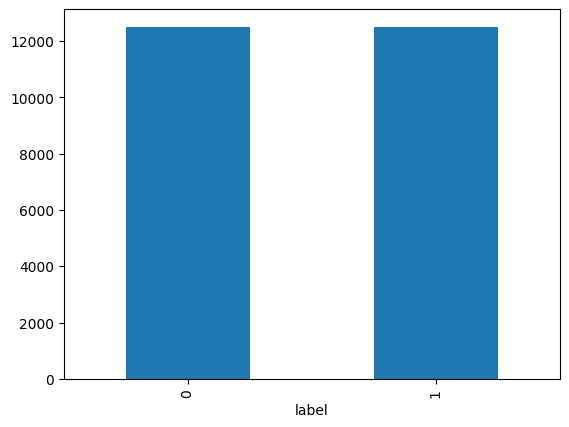

In [9]:
#counts      1:positve /  0:negative
print(train['label'].value_counts())

train['label'].value_counts().plot(kind='bar')

## Cleaning

In [12]:
import re
import string
import nltk
from bs4 import BeautifulSoup
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

Download neccessery libraries

In [13]:
# tokenizer
# Splits text into individual words
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [14]:
# stopwords list
# common words like "the", "is", "and"
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [15]:
#  WordNet dictionary
# Needed for lemmatization (base word conversion)
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to /root/nltk_data...


In [16]:
#  English stopwords set
# Stores unnecessary common words for removal
stop_words = set(stopwords.words('english'))

# keep necessary words for review
stop_words.discard('not')
stop_words.discard('no')
stop_words.discard('nor')
stop_words.discard('never')
stop_words.discard('but')

The preprocessing functions both clean the reviews by convert characters to lowercase, remove links, punctuation marks except HTML tags, numbers, extra spaces, and lemmatizing words.

The second function removes stop words as an extra step, but keeps some important negation words, because they can change sentiment meaning.

In [17]:
# preprocessing function keeps stop words
def preprocess_stop_words(text):

    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove punctuation except HTML symbols (< > /)
    punctuation_without_html = string.punctuation.replace('<', '').replace('>', '').replace('/', '')
    text = text.translate(str.maketrans('', '', punctuation_without_html))

    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return ' '.join(tokens)

In [18]:
# preprocessing function removes stop words
def preprocess_without_stop_words(text):

    text = text.lower()

    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    # Remove punctuation except HTML symbols (< > /)
    punctuation_without_html = string.punctuation.replace('<', '').replace('>', '').replace('/', '')

    text = text.translate(str.maketrans('', '', punctuation_without_html))

    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    #remove stop words
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return ' '.join(tokens)

In [19]:
#create new column for clean_text_with_stop_words and apply appropriate preprocessing

train['clean_text_with_stop_words'] = train['text'].apply(preprocess_stop_words)
test['clean_text_with_stop_words'] = test['text'].apply(preprocess_stop_words)

In [20]:
#create new column for clean_text_without_stop_words and apply appropriate preprocessing

train['clean_text_without_stop_words'] = train['text'].apply(preprocess_without_stop_words)
test['clean_text_without_stop_words'] = test['text'].apply(preprocess_without_stop_words)

In [21]:
train.columns

Index(['text', 'label', 'clean_text_with_stop_words',
       'clean_text_without_stop_words'],
      dtype='object')

In [22]:
#show the result of the preprocessing technique
print('Original Review:')
print(train['text'][0])

print('\nCleaned Review With Stop Words:')
print(train['clean_text_with_stop_words'][0])

print('\nCleaned Review Without Stop Words:')
print(train['clean_text_without_stop_words'][0])

Original Review:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and

# Traditional models

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from nltk import pos_tag
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

<b>Training evaluation function</b> is created to avoid repeting the same training and evaluation code for every model

In [24]:
# Labels
y_train = train['label']
y_test = test['label']

def train_evaluate_model(model, X_train, X_test, y_train, y_test, title):

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    print(title)
    print('\nAccuracy:', accuracy)
    print('\nClassification Report:',(classification_report(y_test, y_pred)))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Negative', 'Positive'])
    disp.plot(cmap='Blues')
    plt.title(title)
    plt.show()

    return model, y_pred, accuracy



---



## Feature Extraction TF-IDF

TF-IDF vectorization is used to convert text into numrical features, because ML models can not work with row text directly, so each review is represented as vector of weights

In [25]:
vectorizer_with_stop_words = TfidfVectorizer(
    max_features=7000,
    ngram_range=(1,1),
    min_df=5,
    max_df=0.8
)

# Fit on train
X_train_with_stop_words = vectorizer_with_stop_words.fit_transform(train['clean_text_with_stop_words'])
# Transform test
X_test_with_stop_words = vectorizer_with_stop_words.transform(test['clean_text_with_stop_words'])

In [26]:
# without_stop_words
vectorizer_without_stop_words = TfidfVectorizer(
    max_features=7000,
    ngram_range=(1,1),
    min_df=5,
    max_df=0.8
)

# Fit on train
X_train_without_stop_words =  vectorizer_without_stop_words.fit_transform(train['clean_text_without_stop_words'])
# Transform test
X_test_without_stop_words=  vectorizer_without_stop_words.transform(test['clean_text_without_stop_words'])

the TF-IDF vectorization created 7K new columns for each word type, due to removing stop words from one column and keep it in the other one, we have got 2 diffrent sets of words

In [27]:
feature_names_with_stop_words = vectorizer_with_stop_words.get_feature_names_out()

print('First 20 features With Stop Words:')
print(feature_names_with_stop_words[:20])

First 20 features With Stop Words:
['aaron' 'abandon' 'abandoned' 'abc' 'ability' 'able' 'abomination'
 'abortion' 'abound' 'about' 'above' 'abraham' 'abrupt' 'abruptly'
 'absence' 'absent' 'absolute' 'absolutely' 'absorbing' 'absurd']


In [28]:
feature_names_without_stop_words = vectorizer_without_stop_words.get_feature_names_out()

print('First 20 features Without Stop Words:')
print(feature_names_without_stop_words[:20])

First 20 features Without Stop Words:
['aaron' 'abandon' 'abandoned' 'abc' 'ability' 'able' 'abomination'
 'abortion' 'abound' 'about' 'abraham' 'abrupt' 'abruptly' 'absence'
 'absent' 'absolute' 'absolutely' 'absorbing' 'absurd' 'absurdity']


In [29]:
#display the TF-IDF table values with stop words

X_train_df= pd.DataFrame(
    X_train_with_stop_words.toarray(),
    columns=feature_names_with_stop_words
)

X_train_df.head()

,aaron,abandon,abandoned,abc,ability,able,abomination,abortion,abound,about,...,youtube,youve,zane,zero,zizek,zombi,zombie,zone,zoom,zorro
0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.112678,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.09206,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.028068,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [30]:
#display the TF-IDF table values without stop words

X_train_without_stop_words_df= pd.DataFrame(
    X_train_without_stop_words.toarray(),
    columns=feature_names_without_stop_words
)

X_train_without_stop_words_df.head()

,aaron,abandon,abandoned,abc,ability,able,abomination,abortion,abound,about,...,youtube,youve,zane,zero,zizek,zombi,zombie,zone,zoom,zorro
0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.097993,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


##TF-IDF + Logistic Regression




Training Logistic Regression model with and without stop words using the predifend train_evaluate_model function

Logistic Regression With Stop Word

Accuracy: 0.88152

Classification Report:               precision    recall  f1-score   support

           0       0.88      0.88      0.88     12500
           1       0.88      0.88      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



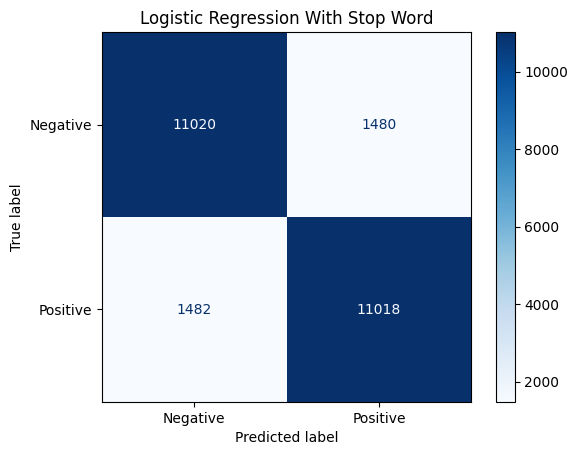

In [31]:
# Logistic Regression Model With Stop_Word
log_model_with_stop_words, y_pred_log, accuracy_log = train_evaluate_model(
    LogisticRegression(max_iter=1000),
    X_train_with_stop_words,
    X_test_with_stop_words,
    y_train,
    y_test,
    'Logistic Regression With Stop Word'
)

Logistic Regression Without Stop Words

Accuracy: 0.88072

Classification Report:               precision    recall  f1-score   support

           0       0.88      0.88      0.88     12500
           1       0.88      0.88      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



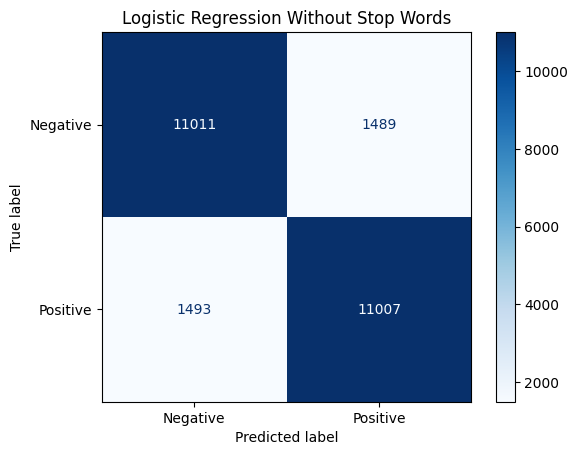

In [32]:
# Logistic Regression Model Without Stop_Word
log_model_without_stop_words, y_pred_log_without, accuracy_log_without = train_evaluate_model(
    LogisticRegression(max_iter=1000),
    X_train_without_stop_words,
    X_test_without_stop_words,
    y_train,
    y_test,
    'Logistic Regression Without Stop Words'
)

##N-grams (1,2) + SVM

N-gram converts texts into numrical featurs using bigram, because ML models can not work with row text directly.

In [33]:
ngram_vectorizer_with_stop_words = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=5,
    max_df=0.8
)

# Fit on train
X_train_ngram_with_stop_words = ngram_vectorizer_with_stop_words.fit_transform(train['clean_text_with_stop_words'])
# Transform test
X_test_ngram_with_stop_words = ngram_vectorizer_with_stop_words.transform(test['clean_text_with_stop_words'])

In [34]:
ngram_vectorizer_without_stop_words = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=5,
    max_df=0.8
)

# Fit on train
X_train_ngram_without_stop_words = ngram_vectorizer_without_stop_words.fit_transform(train['clean_text_without_stop_words'])
# Transform test
X_test_ngram_without_stop_words = ngram_vectorizer_without_stop_words.transform(test['clean_text_without_stop_words'])

Training Support Vector Machine Model with and without stop words using the predifend train_evaluate_model function

SVM With StopWord

Accuracy: 0.87968

Classification Report:               precision    recall  f1-score   support

           0       0.88      0.87      0.88     12500
           1       0.88      0.89      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



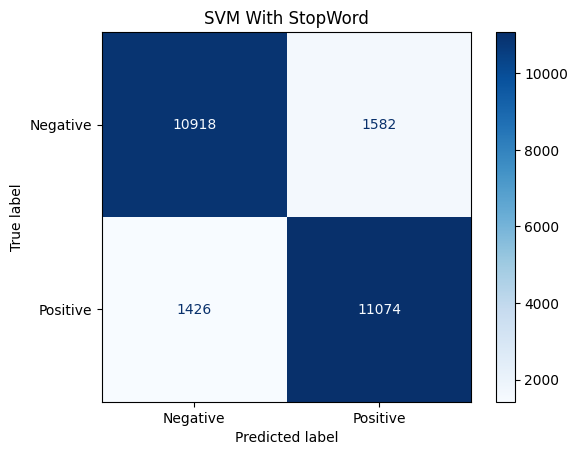

In [35]:
# Support Vector Machine Model With Stop_Word
svm_model_with_stop_words, y_pred_svm, accuracy_svm = train_evaluate_model(
    LinearSVC(),
    X_train_ngram_with_stop_words,
    X_test_ngram_with_stop_words,
    y_train,
    y_test,
    'SVM With StopWord'
)

SVM Without Stop Words

Accuracy: 0.871

Classification Report:               precision    recall  f1-score   support

           0       0.87      0.87      0.87     12500
           1       0.87      0.87      0.87     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000



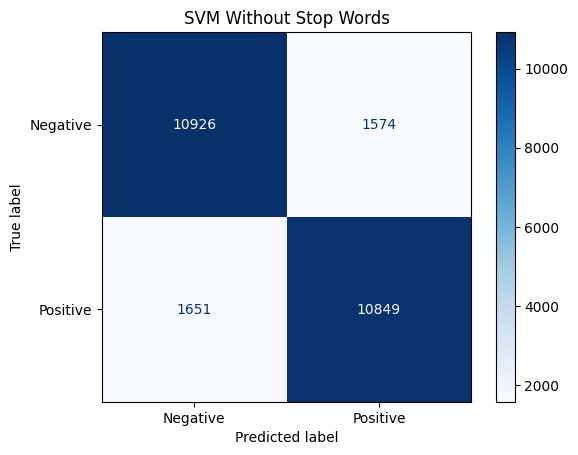

In [36]:
# Support Vector Machine Model Without Stop_Word
svm_model_without_stop_words, y_pred_svm_without, accuracy_svm_without = train_evaluate_model(
    LinearSVC(),
    X_train_ngram_without_stop_words,
    X_test_ngram_without_stop_words,
    y_train,
    y_test,
    'SVM Without Stop Words'
)

##POS + Naive Bayes

POS is used to create a table of grammetical tags along with counts of each tag in each sentence, POS doesn't provide any information abot semantics only the type of words

In [37]:
#download NLTK resources needed for tekonization and POS tagging
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [38]:
# Extract POS tas from text
def get_pos_tags(text):
    tokens = word_tokenize(text)
    tags = pos_tag(tokens)
    return " ".join([tag for word, tag in tags])

In [39]:
# Apply POS tagging function with text that has stop words

train['pos_text'] = train['clean_text_with_stop_words'].apply(get_pos_tags)
test['pos_text'] = test['clean_text_with_stop_words'].apply(get_pos_tags)

train[['clean_text_with_stop_words', 'pos_text']].head()

,clean_text_with_stop_words,pos_text
0,i rented i am curiousyellow from my video stor...,NN VBD JJ VBP NN IN PRP$ NN NN IN IN PDT DT NN...
1,i am curious yellow is a risible and pretentio...,NN VBP JJ NN VBZ DT JJ CC JJ VBG NN PRP VBZ JJ...
2,if only to avoid making this type of film in t...,IN RB TO VB VBG DT NN IN NN IN DT NN DT NN VBZ...
3,this film wa probably inspired by godard mascu...,DT NN NN RB VBN IN NN NN NN CC VB NN PRP TO VB...
4,oh brotherafter hearing about this ridiculous ...,UH NN VBG IN DT JJ NN IN JJ NN DT VBP MD VB IN...


In [40]:
# Apply POS tagging function with text that has no stop words

train['pos_text_without_stop_words'] = train['clean_text_without_stop_words'].apply(get_pos_tags)
test['pos_text_without_stop_words'] = test['clean_text_without_stop_words'].apply(get_pos_tags)

train[['clean_text_without_stop_words', 'pos_text_without_stop_words']].head()

,clean_text_without_stop_words,pos_text_without_stop_words
0,rented curiousyellow video store controversy s...,VBN JJ NN NN NN VBD RB VBN RB VBN RB VBN JJ NN...
1,curious yellow risible pretentious steaming pi...,JJ CC JJ JJ VBG JJ NN NN CD JJ NN NN RB VBN RB...
2,avoid making type film future film interesting...,NN VBG JJ NN NN NN JJ NN CC VBP DT NN NN NNP N...
3,film probably inspired godard masculin féminin...,NN RB VBD JJ NN NN NN VBP NN RB NNP NN NNP NNP...
4,oh brotherafter hearing ridiculous film umptee...,UH NN VBG JJ NN JJ NN VBP JJ NN NN NN NNP NN N...


convert the table of POS tags with stop words to numbers to be suitable for ML models

In [41]:
pos_vectorizer_with_stop_words = CountVectorizer()

X_train_pos_with_stop_word = pos_vectorizer_with_stop_words.fit_transform(train['pos_text'])
X_test_pos_with_stop_word = pos_vectorizer_with_stop_words.transform(test['pos_text'])

print('X_train With stop_word shape:', X_train_pos_with_stop_word.shape)
print('X_test With stop_word shape:', X_test_pos_with_stop_word.shape)

X_train With stop_word shape: (25000, 33)
X_test With stop_word shape: (25000, 33)


printing the sentnace from the text table along with the numrical tags from the vectorized table

In [42]:
print(train['clean_text_with_stop_words'][0],'\n')
print(X_train_pos_with_stop_word[0])

i rented i am curiousyellow from my video store because of all the controversy that surrounded it when it wa first released in i also heard that at first it wa seized by u custom if it ever tried to enter this country therefore being a fan of film considered controversial i really had to see this for myself<br /><br />the plot is centered around a young swedish drama student named lena who want to learn everything she can about life in particular she want to focus her attention to making some sort of documentary on what the average swede thought about certain political issue such a the vietnam war and race issue in the united state in between asking politician and ordinary denizen of stockholm about their opinion on politics she ha sex with her drama teacher classmate and married men<br /><br />what kill me about i am curiousyellow is that year ago this wa considered pornographic really the sex and nudity scene are few and far between even then it not shot like some cheaply made porno 

convert the table of POS tags with stop words to numbers to be suitable for ML models

In [43]:
pos_vectorizer_without_stop_words = CountVectorizer()

X_train_pos_without_stop_words = pos_vectorizer_without_stop_words.fit_transform(train['pos_text_without_stop_words'])
X_test_pos_without_stop_words = pos_vectorizer_without_stop_words.transform(test['pos_text_without_stop_words'])

In [44]:
print(train['clean_text_without_stop_words'][0],'\n')
print(X_train_pos_without_stop_words[0])

rented curiousyellow video store controversy surrounded first released also heard first seized u custom ever tried enter country therefore fan film considered controversial really see myself<br /><br />the plot centered around young swedish drama student named lena want learn everything life particular want focus attention making sort documentary average swede thought certain political issue vietnam war race issue united state asking politician ordinary denizen stockholm opinion politics sex drama teacher classmate married men<br /><br />what kill curiousyellow year ago considered pornographic really sex nudity scene far even not shot like cheaply made porno countryman mind find shocking reality sex nudity major staple swedish cinema even ingmar bergman arguably answer good old boy john ford sex scene films<br /><br />i commend filmmaker fact sex shown film shown artistic purpose rather shock people make money shown pornographic theater america curiousyellow good film anyone wanting st

Apply Navive bayes model to the preprocessed tables from POS tagging

Naive Bayes POS With Stop Word

Accuracy: 0.59048

Classification Report:               precision    recall  f1-score   support

           0       0.59      0.57      0.58     12500
           1       0.59      0.61      0.60     12500

    accuracy                           0.59     25000
   macro avg       0.59      0.59      0.59     25000
weighted avg       0.59      0.59      0.59     25000



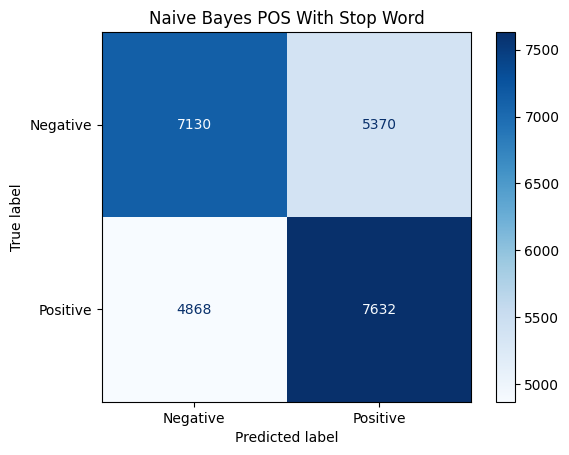

In [45]:
# Naive Bayes Model With Stop Word
nb_model_with_stop_words, y_pred_nb, accuracy_nb = train_evaluate_model(
    MultinomialNB(),
    X_train_pos_with_stop_word,
    X_test_pos_with_stop_word,
    y_train,
    y_test,
    'Naive Bayes POS With Stop Word'
)

Naive Bayes POS Without Stop Word

Accuracy: 0.56676

Classification Report:               precision    recall  f1-score   support

           0       0.57      0.52      0.54     12500
           1       0.56      0.62      0.59     12500

    accuracy                           0.57     25000
   macro avg       0.57      0.57      0.57     25000
weighted avg       0.57      0.57      0.57     25000



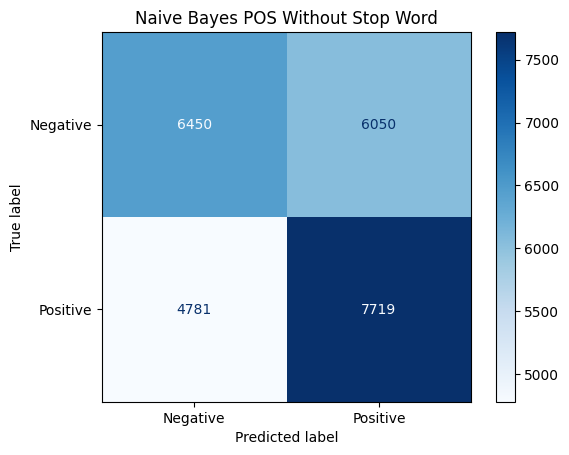

In [46]:
# Naive Bayes Model Without Stop Word
nb_model_without_stop_words, y_pred_nb_without, accuracy_nb_without = train_evaluate_model(
    MultinomialNB(),
    X_train_pos_without_stop_words,
    X_test_pos_without_stop_words,
    y_train,
    y_test,
    'Naive Bayes POS Without Stop Word'
)

#Comparison

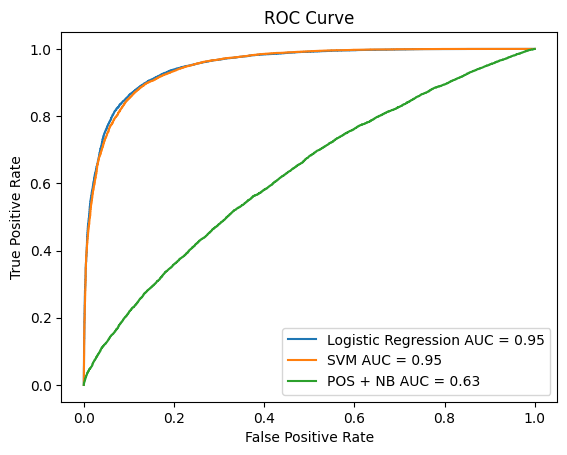

In [47]:
#ROC Curve comparison
y_log = log_model_with_stop_words.predict_proba(X_test_with_stop_words)[:,1]
y_svm = svm_model_with_stop_words.decision_function(X_test_ngram_with_stop_words)
y_nb = nb_model_with_stop_words.predict_proba(X_test_pos_with_stop_word)[:,1]

# ROC
fpr_log, tpr_log, _ = roc_curve(y_test, y_log)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_svm)
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_nb)


plt.plot(fpr_log, tpr_log,
         label=f'Logistic Regression AUC = {auc(fpr_log,tpr_log):.2f}')

plt.plot(fpr_svm, tpr_svm,
         label=f'SVM AUC = {auc(fpr_svm,tpr_svm):.2f}')

plt.plot(fpr_nb, tpr_nb,
         label=f'POS + NB AUC = {auc(fpr_nb,tpr_nb):.2f}')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve')

plt.legend()

plt.show()

Logsitc regression and Support Vector Machines (SVM) achieved the highest performance, with AUC scores of 0.95, showing strong sentiment classification capabilities.
However, the POS + Naive Bayes model performed poorly (AUC = 0.63) because POS-based on grammetical tags and does not provide any details about semantics

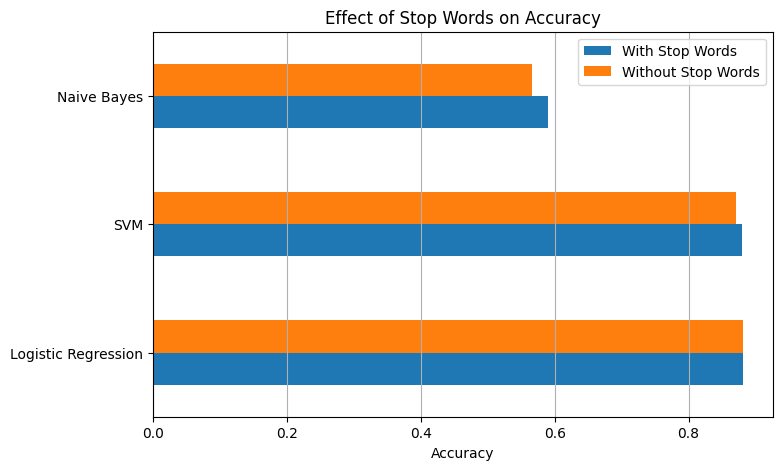

In [48]:
# Results Table
results_df = pd.DataFrame({
    'With Stop Words': [
        accuracy_log,
        accuracy_svm,
        accuracy_nb
    ],

    'Without Stop Words': [
        accuracy_log_without,
        accuracy_svm_without,
        accuracy_nb_without
    ]

}, index=[
    'Logistic Regression',
    'SVM',
    'Naive Bayes'
])


# Plot
results_df.plot(
    kind='barh',
    figsize=(8,5)
)

plt.title('Effect of Stop Words on Accuracy')
plt.xlabel('Accuracy')
plt.grid(axis='x')
plt.show()

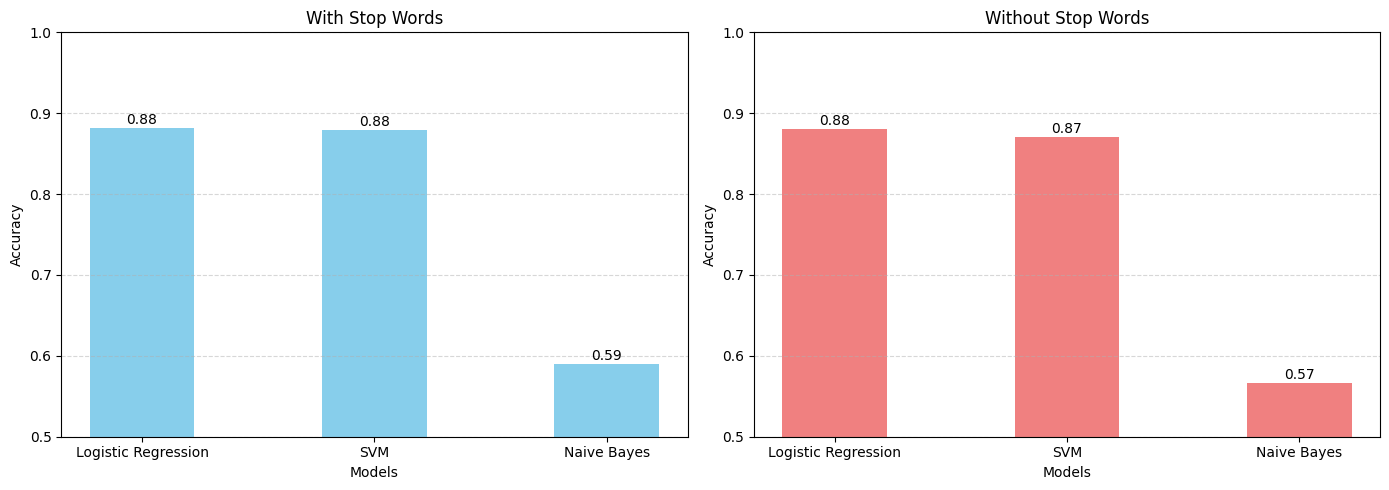

In [52]:

models = ['Logistic Regression', 'SVM', 'Naive Bayes']

# Accuracy
with_stop = [
    accuracy_log,
    accuracy_svm,
    accuracy_nb
]

without_stop = [
    accuracy_log_without,
    accuracy_svm_without,
    accuracy_nb_without
]

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# With Stop Words

bars1 = axes[0].bar(
    models,
    with_stop,
    width=0.45,
    color='skyblue'
)

axes[0].set_title('With Stop Words')
axes[0].set_xlabel('Models')
axes[0].set_ylabel('Accuracy')

axes[0].set_ylim(0.5, 1.0)

axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Show values
for bar in bars1:
    yval = bar.get_height()

    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.005,
        f'{yval:.2f}',
        ha='center'
    )


bars2 = axes[1].bar(
    models,
    without_stop,
    width=0.45,
    color='lightcoral'
)

axes[1].set_title('Without Stop Words')
axes[1].set_xlabel('Models')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.5, 1.0)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars2:
    yval = bar.get_height()

    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.005,
        f'{yval:.2f}',
        ha='center'
    )

plt.tight_layout()

plt.show()

The charts shows the effect of stop words on the accuracy of different machine learning models. Logistic Regression and SVM achieved the highest accuracy, with only a very small difference between using stop words and removing them. This indicates that stop words had minimal impact on these models.
In contrast, the POS + Naive Bayes model achieved lower accuracy overall, and its performance decreased more noticeably after removing stop words. This suggests that stop words contributed useful grammatical information for POS-based features.

Overall, Logistic Regression and SVM demonstrated more stable and reliable performance compared to POS + Naive Bayes.